# Détection de deepfakes par CNN — dataset 140k Real & Fake Faces

Dataset : [`xhlulu/140k-real-and-fake-faces`](https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces)

L'objectif de ce notebook est d'entraîner un réseau de neurones convolutif capable de dire, à
partir des seuls pixels d'un visage, s'il s'agit d'une vraie photo ou d'une image générée.

Le jeu de données réunit 70 000 vrais visages (la base FFHQ, des photos Flickr rassemblées par
NVIDIA) et 70 000 faux visages produits par StyleGAN. C'est un point important : les deux classes
sont de vrais visages, le modèle doit donc apprendre les petits défauts laissés par la génération
et non une différence grossière de style. On verra plus loin pourquoi ce choix de dataset compte.

Une réserve à garder en tête dès le départ : comme tous les faux viennent d'un seul générateur
(StyleGAN), la tâche reste relativement abordable, et rien ne garantit que le modèle reconnaisse
des faux produits autrement (diffusion, échange de visages en vidéo, etc.).

Le notebook se lit en deux parties. La première couvre les données et un modèle de machine learning
classique ; la seconde passe au deep learning avec le CNN.

## 1. Dépendances et imports

In [31]:
# Installation si nécessaire (décommenter au besoin)
#!pip install kagglehub pandas numpy matplotlib scikit-learn tensorflow pillow requests tqdm
import os, io, warnings, random, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image, ImageEnhance, ImageFilter
 
import tensorflow as tf
from tensorflow.keras import layers, models
 
 # --- Machine Learning classique (Partie 1) ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, learning_curve,
                                      validation_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
 
 # Architectures des réseaux : définies dans le module externe models.py (modularité — Jalon global)
import importlib, models as models_mod
importlib.reload(models_mod)
from models import build_cnn, build_mlp, build_transfer_mobilenet, make_augmentation
 
 # Barre de progression : tqdm si disponible, sinon repli qui affiche un pourcentage
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, total=None, desc=""):
        seq = list(iterable) if iterable is not None else []
        total = total or len(seq)
        step = max(1, total // 20)
        for i, x in enumerate(seq, 1):
            if i % step == 0 or i == total:
                print(f"\r{desc} {100*i//total:3d}%", end="", flush=True)
            yield x
        print()
 
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
 
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("Imports OK — TensorFlow", tf.__version__, "| pandas", pd.__version__)

Imports OK — TensorFlow 2.21.0 | pandas 3.0.3


# Partie 1 — Données et machine learning classique

## 2. Choix du dataset

Le sujet demande de partir d'une image pour décider si elle est vraie ou truquée. Il nous faut donc
un jeu d'images étiquetées, équilibré entre les deux classes, assez gros pour entraîner un modèle,
et surtout sans piège qui rendrait la tâche trop facile.

On a d'abord essayé le dataset `deepfake-detection-2026`, qu'on a fini par écarter : ses images
"fake" étaient en réalité des avatars dessinés (dicebear, multiavatar) opposés à des photos. Un CNN
y atteignait 98 % d'accuracy simplement en distinguant une photo d'un dessin, ce qui n'a rien à voir
avec de la détection de deepfakes. C'est une fuite de données déguisée.

Le jeu `140k Real and Fake Faces` corrige ce défaut. Il oppose de vrais visages (FFHQ) à des faux
générés par StyleGAN : des deux côtés, ce sont des visages, et le modèle doit vraiment repérer les
traces de génération. Il est volumineux (70 000 images par classe), parfaitement équilibré, et déjà
découpé en train / validation / test sous forme de dossiers d'images, ce qui simplifie la mise en
place.

### Téléchargement du dataset (kagglehub)

In [32]:
import kagglehub

# Télécharge (et met en cache) le dataset depuis Kaggle (~4 Go la 1re fois)
dataset_dir = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print("Dataset téléchargé dans :", dataset_dir)

Dataset téléchargé dans : C:\Users\Hamza\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2


## 3. Repérage des dossiers d'images

Le dataset range les images dans des dossiers `train`, `valid` et `test`, chacun contenant un
sous-dossier `real` et un sous-dossier `fake`. On les retrouve automatiquement, peu importe la
profondeur d'imbrication, puis on compte les images disponibles dans chacun.

In [33]:
IMG_EXT = (".jpg", ".jpeg", ".png")

def find_split_dirs(root):
    """Repère les dossiers train/val/test qui contiennent des sous-dossiers real/ et fake/."""
    aliases = {"train": "train", "training": "train",
               "valid": "val", "val": "val", "validation": "val",
               "test": "test", "testing": "test"}
    splits = {}
    for dirpath, dirnames, _ in os.walk(root):
        sub = {d.lower() for d in dirnames}
        if {"real", "fake"}.issubset(sub):
            base = os.path.basename(dirpath).lower()
            if base in aliases:
                splits[aliases[base]] = dirpath
    return splits

def _class_dir(split_dir, cls):
    for d in os.listdir(split_dir):
        if d.lower() == cls:
            return os.path.join(split_dir, d)
    raise FileNotFoundError(f"Sous-dossier '{cls}' introuvable dans {split_dir}")

def count_images(d):
    return sum(1 for f in os.listdir(d) if f.lower().endswith(IMG_EXT))

split_dirs = find_split_dirs(dataset_dir)
counts = {s: {cls: count_images(_class_dir(sd, cls)) for cls in ("real", "fake")}
          for s, sd in split_dirs.items()}
counts_df = pd.DataFrame(counts).T.reindex(["train", "val", "test"])[["real", "fake"]]

print("Dossiers détectés :")
for s in ["train", "val", "test"]:
    print(f"  {s:5s}:", split_dirs.get(s, "—"))
print()
print(counts_df)

Dossiers détectés :
  train: C:\Users\Hamza\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\train
  val  : C:\Users\Hamza\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\valid
  test : C:\Users\Hamza\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\test

        real   fake
train  50000  50000
val    10000  10000
test   10000  10000


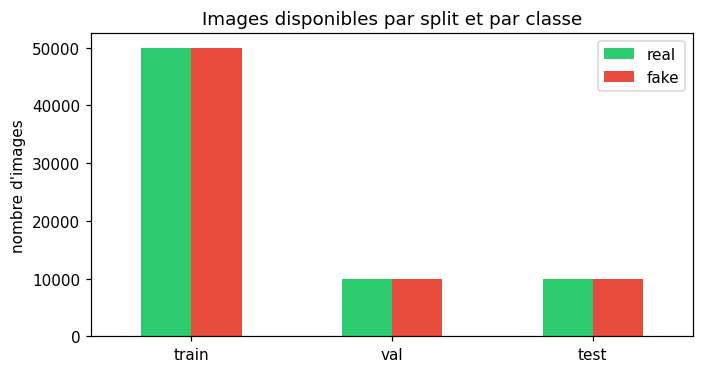

In [34]:
# Nombre d'images disponibles par split et par classe
ax = counts_df.plot.bar(color={"real": "#2ecc71", "fake": "#e74c3c"},
                        figsize=(6.5, 3.5), rot=0)
ax.set_title("Images disponibles par split et par classe")
ax.set_ylabel("nombre d'images"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Chargement des images

Les images sont déjà sur le disque, il n'y a donc rien à télécharger image par image. On charge
un échantillon de chaque classe pour chaque split : les 140 000 images complètes ne tiendraient pas
en mémoire, et un sous-ensemble suffit largement pour ce travail. Les paramètres `N_*_PER_CLASS` se
règlent selon la RAM et le temps disponibles. Chaque image est convertie en RGB et redimensionnée
en `IMG_SIZE × IMG_SIZE`, et une barre de progression suit le chargement.

In [35]:
IMG_SIZE = 128                 # côté des images (carré)
N_TRAIN_PER_CLASS = 1500       # images chargées PAR classe pour l'entraînement (↑ = mieux, + long)
N_VAL_PER_CLASS   = 300
N_TEST_PER_CLASS  = 300

def load_split(split_dir, n_per_class, seed=RANDOM_STATE):
    """Charge jusqu'à n_per_class images par classe depuis un dossier split -> (X uint8, y int)."""
    X, y = [], []
    for cls_name, label in [("real", 1), ("fake", 0)]:     # 1 = REAL, 0 = FAKE
        cls_dir = _class_dir(split_dir, cls_name)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMG_EXT)]
        random.Random(seed).shuffle(files)
        files = files[:n_per_class]
        for f in tqdm(files, total=len(files),
                      desc=f"{os.path.basename(split_dir)}/{cls_name}"):
            try:
                img = Image.open(os.path.join(cls_dir, f)).convert("RGB")
                X.append(np.asarray(img.resize((IMG_SIZE, IMG_SIZE)), dtype="uint8"))
                y.append(label)
            except Exception:
                pass
    return np.array(X), np.array(y)

# --- Inférence sur une image quelconque du web (gardé pour la section 10) ---
_HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"}

def fetch_image(url, timeout=8, retries=2):
    """Télécharge une image depuis une URL -> PIL.Image RGB, ou None en cas d'échec."""
    for attempt in range(retries + 1):
        try:
            r = requests.get(url, timeout=timeout, headers=_HEADERS)
            r.raise_for_status()
            return Image.open(io.BytesIO(r.content)).convert("RGB")
        except Exception:
            if attempt == retries:
                return None

In [36]:
print("Chargement des images depuis les dossiers locaux...")
X_train, y_train = load_split(split_dirs["train"], N_TRAIN_PER_CLASS)
X_val,   y_val   = load_split(split_dirs["val"],   N_VAL_PER_CLASS)
X_test,  y_test  = load_split(split_dirs["test"],  N_TEST_PER_CLASS)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Répartition train [FAKE, REAL] :", np.bincount(y_train))

Chargement des images depuis les dossiers locaux...


test/fake: 100%|██████████| 300/300 [00:00<00:00, 771.71it/s]

Train : (3000, 128, 128, 3) | Val : (600, 128, 128, 3) | Test : (600, 128, 128, 3)
Répartition train [FAKE, REAL] : [1500 1500]


## 5. Analyse exploratoire (EDA)

Avant de modéliser, on regarde un peu les données chargées (toujours avant augmentation) : quelques
statistiques par classe, une vérification des images douteuses, et enfin un aperçu visuel.

### 5.1 Statistiques descriptives

On résume chaque image par quelques chiffres simples : son intensité moyenne, son contraste et la
moyenne de chaque canal de couleur. En comparant ces distributions entre REAL et FAKE, on voit si
un indice global évident sépare les deux classes (en pratique, les statistiques sont très proches,
ce qui annonce déjà qu'un modèle linéaire aura du mal).

Moyennes des descripteurs par classe :
       intensite_moy  contraste           R           G          B
label                                                             
FAKE      112.260002  60.639999  132.410004  108.220001  96.139999
REAL      113.970001  62.529999  134.660004  109.660004  97.589996

Écart-type des descripteurs par classe :
       intensite_moy  contraste
label                          
FAKE       26.860001      10.45
REAL       27.170000       9.76


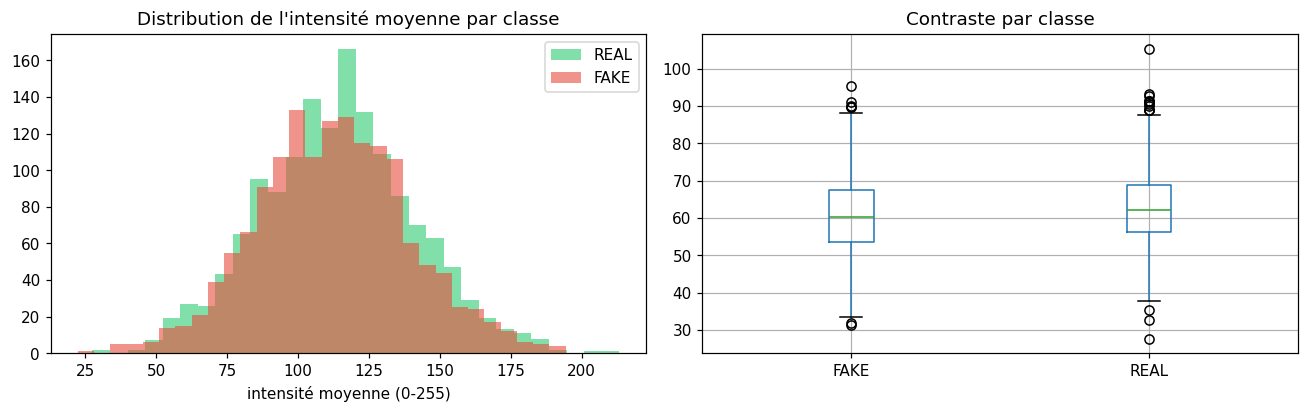

In [37]:
def image_feature_table(X, y):
    """Descripteurs simples par image (sur les pixels 0-255)."""
    Xf = X.astype("float32")
    return pd.DataFrame({
        "intensite_moy": Xf.mean(axis=(1, 2, 3)),
        "contraste":     Xf.std(axis=(1, 2, 3)),
        "R": Xf[..., 0].mean(axis=(1, 2)),
        "G": Xf[..., 1].mean(axis=(1, 2)),
        "B": Xf[..., 2].mean(axis=(1, 2)),
        "label": np.where(y == 1, "REAL", "FAKE"),
    })

feat = image_feature_table(X_train, y_train)
print("Moyennes des descripteurs par classe :")
print(feat.groupby("label")[["intensite_moy", "contraste", "R", "G", "B"]].mean().round(2))
print("\nÉcart-type des descripteurs par classe :")
print(feat.groupby("label")[["intensite_moy", "contraste"]].std().round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lab, col in [("REAL", "#2ecc71"), ("FAKE", "#e74c3c")]:
    ax[0].hist(feat.loc[feat.label == lab, "intensite_moy"], bins=30,
               alpha=0.6, label=lab, color=col)
ax[0].set_title("Distribution de l'intensité moyenne par classe")
ax[0].set_xlabel("intensité moyenne (0-255)"); ax[0].legend()
feat.boxplot(column="contraste", by="label", ax=ax[1])
ax[1].set_title("Contraste par classe"); ax[1].set_xlabel(""); plt.suptitle("")
plt.tight_layout(); plt.show()

### 5.2 Détection d'anomalies

On vérifie que les données sont saines : images presque uniformes (souvent un signe de fichier vide
ou corrompu), images quasiment en niveaux de gris, doublons exacts, et valeurs d'intensité
aberrantes repérées avec la règle de l'écart interquartile. On termine par un coup d'œil aux images
les plus sombres et les plus claires pour s'assurer qu'il ne s'agit pas de cas problématiques.

Images analysées                           : 3000
Images quasi-uniformes (vides/corrompues)  : 0
Images quasi en niveaux de gris            : 0
Doublons exacts                            : 0
Outliers d'intensité (règle IQR)           : 23


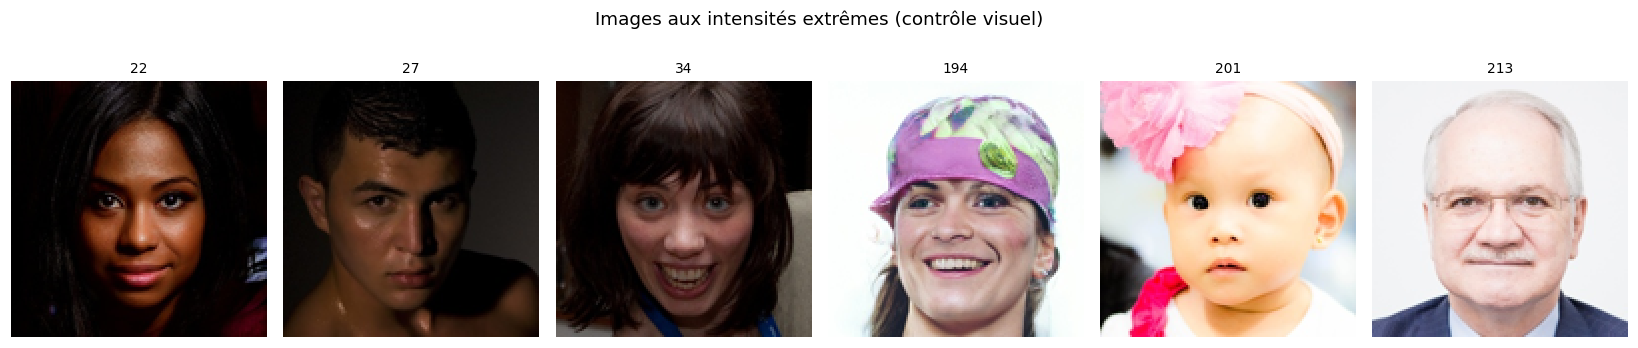

In [38]:
flat = X_train.reshape(len(X_train), -1).astype("float32")
std_per_img = flat.std(axis=1)
mean_per_img = flat.mean(axis=1)

# 1) Images quasi-uniformes (potentiellement vides / corrompues)
blank = np.where(std_per_img < 5)[0]
# 2) Images quasi en niveaux de gris (faible écart entre canaux R, G, B)
chan_spread = X_train.astype("float32").std(axis=3).mean(axis=(1, 2))
grayscale = np.where(chan_spread < 3)[0]
# 3) Doublons exacts (hash des pixels)
seen, dups = {}, []
for i in range(len(X_train)):
    h = hashlib.md5(X_train[i].tobytes()).hexdigest()
    dups.append(i) if h in seen else seen.update({h: i})
# 4) Valeurs extrêmes d'intensité (méthode IQR)
q1, q3 = np.percentile(mean_per_img, [25, 75]); iqr = q3 - q1
outliers = np.where((mean_per_img < q1 - 1.5*iqr) | (mean_per_img > q3 + 1.5*iqr))[0]

print(f"Images analysées                           : {len(X_train)}")
print(f"Images quasi-uniformes (vides/corrompues)  : {len(blank)}")
print(f"Images quasi en niveaux de gris            : {len(grayscale)}")
print(f"Doublons exacts                            : {len(dups)}")
print(f"Outliers d'intensité (règle IQR)           : {len(outliers)}")

# Visualisation de quelques cas extrêmes (les + sombres / + clairs)
extremes = np.concatenate([mean_per_img.argsort()[:3], mean_per_img.argsort()[-3:]])
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle("Images aux intensités extrêmes (contrôle visuel)", y=1.05)
for ax, i in zip(axes, extremes):
    ax.imshow(X_train[i]); ax.axis("off")
    ax.set_title(f"{mean_per_img[i]:.0f}", fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 Visualisation d'exemples

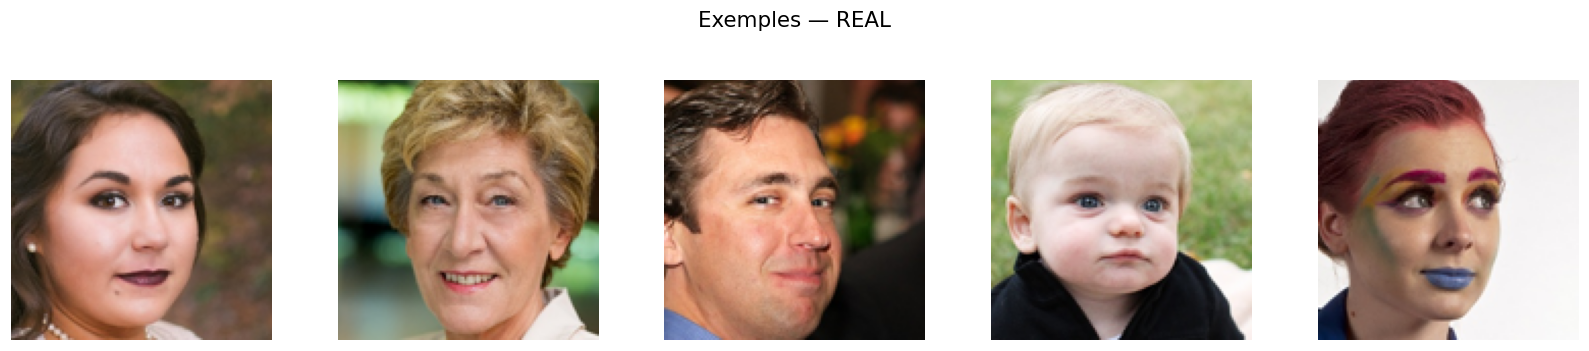

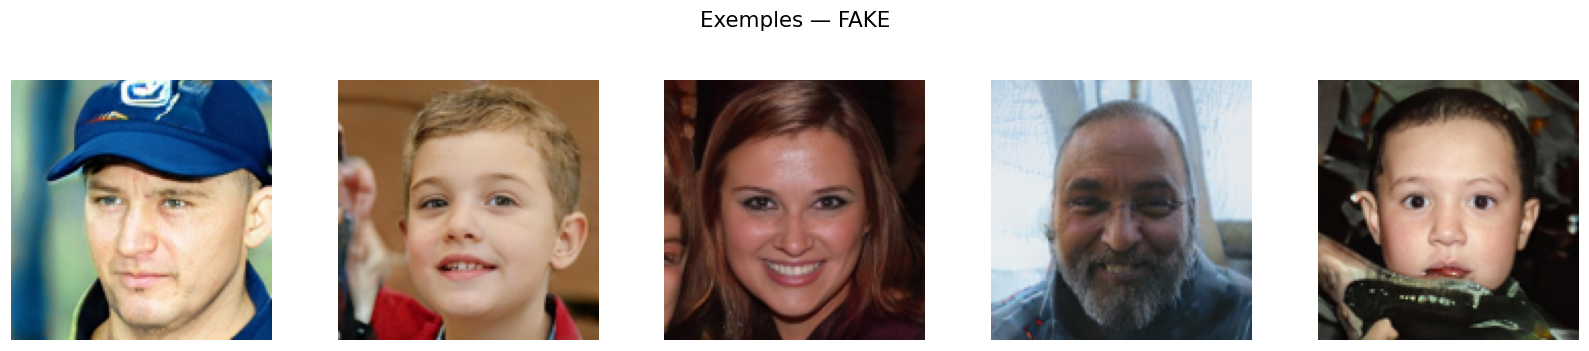

In [39]:
def show_grid(X, y, label_int, label_str, n=5):
    idx = np.where(y == label_int)[0][:n]
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    fig.suptitle(f"Exemples — {label_str}", fontsize=14, y=1.05)
    for ax, i in zip(axes, idx):
        ax.imshow(X[i]); ax.axis("off")
    plt.tight_layout(); plt.show()

show_grid(X_train, y_train, 1, "REAL")
show_grid(X_train, y_train, 0, "FAKE")

## 6. Préparation des données

Les trois jeux train, validation et test viennent directement du dataset (dossiers séparés), il n'y
a donc pas de découpage à refaire. On augmente ensuite uniquement le jeu d'entraînement : la
validation et le test restent des images intactes, sinon les scores seraient trompeurs.

In [40]:
# Récapitulatif des jeux fournis par le dataset
print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print("Train [FAKE, REAL] :", np.bincount(y_train))
print("Val   [FAKE, REAL] :", np.bincount(y_val))
print("Test  [FAKE, REAL] :", np.bincount(y_test))

Train : 3000 | Val : 600 | Test : 600
Train [FAKE, REAL] : [1500 1500]
Val   [FAKE, REAL] : [300 300]
Test  [FAKE, REAL] : [300 300]


### 6.1 Augmentation du jeu d'entraînement

Pour donner plus de matière au modèle, on fabrique plusieurs variantes de chaque image
d'entraînement. Chacune reste réaliste mais introduit une petite perturbation, ce qui pousse le
réseau à devenir plus robuste : miroir horizontal, variations de luminosité, de contraste et de
couleur, compression JPEG agressive (comme après un partage sur le web), bruit de capteur, léger
flou et petite rotation. Avec `AUG_PER_IMAGE` variantes par image, le jeu d'entraînement est
multiplié par `1 + AUG_PER_IMAGE`.

In [41]:
AUG_PER_IMAGE = 5      # nb de variantes générées par image -> dataset x(1 + AUG_PER_IMAGE)

def _to_img(arr):
    return Image.fromarray(arr.astype("uint8"))

def _to_arr(img):
    return np.asarray(img.resize((IMG_SIZE, IMG_SIZE)), dtype="uint8")

# --- Banque de transformations (chacune prend et renvoie un PIL.Image) ---
def t_mirror(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def t_brightness(img):
    return ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))

def t_contrast(img):
    return ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.4))

def t_color(img):
    return ImageEnhance.Color(img).enhance(random.uniform(0.6, 1.5))

def t_rotate(img):
    return img.rotate(random.uniform(-12, 12), resample=Image.BILINEAR)

def t_jpeg(img):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=random.randint(15, 45))
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def t_noise(img):
    arr = np.asarray(img, dtype="int16")
    noise = np.random.normal(0, random.uniform(8, 22), arr.shape)
    return _to_img(np.clip(arr + noise, 0, 255))

def t_blur(img):
    return img.filter(ImageFilter.GaussianBlur(random.uniform(0.6, 1.6)))

TRANSFORMS = [t_mirror, t_brightness, t_contrast, t_color, t_rotate, t_jpeg, t_noise, t_blur]

def augment_training_set(X, y, aug_per_image):
    """Ajoute aug_per_image variantes bruitées par image. Renvoie (X, y) mélangés."""
    aug_X, aug_y = [], []
    k = min(aug_per_image, len(TRANSFORMS))
    for i in tqdm(range(len(X)), total=len(X), desc="Augmentation"):
        base = _to_img(X[i])
        for t in random.sample(TRANSFORMS, k):
            try:
                aug_X.append(_to_arr(t(base)))
                aug_y.append(y[i])
            except Exception:
                pass
    X_out = np.concatenate([X, np.array(aug_X, dtype="uint8")], axis=0)
    y_out = np.concatenate([y, np.array(aug_y)], axis=0)
    # Mélange train + variantes
    order = np.random.permutation(len(X_out))
    return X_out[order], y_out[order]

# Sauvegarde du train NON augmenté (servira à la baseline ML — Partie 1, sans fuite par doublons)
X_train_raw, y_train_raw = X_train.copy(), y_train.copy()

n_before = len(X_train)
X_train, y_train = augment_training_set(X_train, y_train, AUG_PER_IMAGE)
print(f"Train : {n_before} -> {len(X_train)} images après augmentation "
      f"(x{len(X_train)/max(n_before,1):.1f})")
print("Répartition train [FAKE, REAL] :", np.bincount(y_train))

# Poids de classe (calculés sur le train augmenté)
classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Poids de classe :", class_weight)

Augmentation: 100%|██████████| 3000/3000 [00:03<00:00, 840.17it/s]


Train : 3000 -> 18000 images après augmentation (x6.0)
Répartition train [FAKE, REAL] : [9000 9000]
Poids de classe : {0: 1.0, 1: 1.0}


## 7. Un modèle de machine learning classique

Avant de sortir l'artillerie lourde, on entraîne un modèle simple qui servira de point de
comparaison : une régression logistique sur les pixels aplatis d'images réduites à 32×32. On
l'entraîne sur le jeu d'entraînement non augmenté, pour éviter que des variantes quasi identiques
ne se retrouvent à la fois en apprentissage et en validation croisée.

C'est aussi l'occasion d'illustrer la régularisation. En classification, la régression logistique
pénalisée correspond directement à Ridge, Lasso et ElasticNet. La pénalité L2 (Ridge) rétrécit tous
les coefficients sans jamais les annuler, ce qui stabilise le modèle. La pénalité L1 (Lasso) en met
beaucoup à zéro et réalise donc une sélection de variables, le modèle devient creux. ElasticNet
combine les deux et offre un compromis. Dans scikit-learn, le paramètre C est l'inverse de la
force de régularisation : plus C est petit, plus on régularise. On compare les trois et on
regarde la sparsité (le nombre de coefficients non nuls) que chacune produit.

In [42]:
ML_SIZE = 32   # images réduites pour le ML : 32x32x3 = 3072 features

def to_flat_features(X, size=ML_SIZE):
    """Réduit chaque image à size×size et l'aplatit en vecteur normalisé [0,1]."""
    out = np.empty((len(X), size * size * 3), dtype="float32")
    for i in tqdm(range(len(X)), total=len(X), desc=f"Features {size}x{size}"):
        img = Image.fromarray(X[i]).resize((size, size))
        out[i] = np.asarray(img, dtype="float32").reshape(-1) / 255.0
    return out

# Train NON augmenté (pas de doublons) + test
Xtr_flat = to_flat_features(X_train_raw)
Xte_flat = to_flat_features(X_test)
print("Features ML :", Xtr_flat.shape, "| test :", Xte_flat.shape)

# Comparaison des régularisations (équivalents classification de Ridge / Lasso / ElasticNet)
reg_configs = [
    ("Ridge (L2)",  dict(penalty="l2",         solver="liblinear")),
    ("Lasso (L1)",  dict(penalty="l1",         solver="liblinear")),
    ("ElasticNet",  dict(penalty="elasticnet", solver="saga", l1_ratio=0.5, max_iter=2000)),
]

rows, fitted = [], {}
for name, params in reg_configs:
    print(f"Config : {name, params}")
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, **params))
    t0 = time.time(); clf.fit(Xtr_flat, y_train_raw); dt = time.time() - t0
    coef = clf.named_steps["logisticregression"].coef_.ravel()
    p = clf.predict_proba(Xte_flat)[:, 1]
    rows.append({"régularisation": name,
                 "acc_test": round(accuracy_score(y_test, (p >= 0.5).astype(int)), 4),
                 "auc_test": round(roc_auc_score(y_test, p), 4),
                 "coefs_non_nuls": int(np.sum(np.abs(coef) > 1e-6)),
                 "temps_s": round(dt, 1)})
    fitted[name] = clf

reg_df = pd.DataFrame(rows)
print(reg_df.to_string(index=False))
print(f"(nombre total de coefficients : {Xtr_flat.shape[1]})")

# Meilleure baseline retenue pour la comparaison ML vs DL (section 13)
best_name = reg_df.sort_values("auc_test", ascending=False).iloc[0]["régularisation"]
baseline = fitted[best_name]
prob_ml = baseline.predict_proba(Xte_flat)[:, 1]
pred_ml = (prob_ml >= 0.5).astype(int)
acc_ml = accuracy_score(y_test, pred_ml)
auc_ml = roc_auc_score(y_test, prob_ml)
t_ml = float(reg_df.set_index("régularisation").loc[best_name, "temps_s"])
print(f"\nMeilleure baseline : {best_name}  (acc={acc_ml:.3f}, AUC={auc_ml:.3f})")
print(classification_report(y_test, pred_ml, target_names=["FAKE", "REAL"]))

Features 32x32: 100%|██████████| 600/600 [00:00<00:00, 10096.05it/s]


Features ML : (3000, 3072) | test : (600, 3072)
Config : ('Ridge (L2)', {'penalty': 'l2', 'solver': 'liblinear'})
Config : ('Lasso (L1)', {'penalty': 'l1', 'solver': 'liblinear'})
Config : ('ElasticNet', {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5, 'max_iter': 2000})
régularisation  acc_test  auc_test  coefs_non_nuls  temps_s
    Ridge (L2)    0.7467    0.8099            3072      5.7
    Lasso (L1)    0.7450    0.8312            1096      8.4
    ElasticNet    0.7383    0.8187            2236    157.4
(nombre total de coefficients : 3072)

Meilleure baseline : Lasso (L1)  (acc=0.745, AUC=0.831)
              precision    recall  f1-score   support

        FAKE       0.73      0.77      0.75       300
        REAL       0.76      0.72      0.74       300

    accuracy                           0.74       600
   macro avg       0.75      0.74      0.74       600
weighted avg       0.75      0.74      0.74       600



## 8. Évaluation du modèle classique et compromis biais/variance

L'accuracy sur le test ne dit pas tout. Pour comprendre ce qui limite le modèle, on regarde le
compromis biais/variance. Un grand écart entre le score d'entraînement et le score de test trahit
du surapprentissage (variance élevée), tandis que deux scores faibles ensemble indiquent plutôt du
sous-apprentissage (biais élevé). La courbe d'apprentissage, qui trace le score selon la quantité de
données, montre si rajouter des exemples aiderait. La courbe de validation, qui fait varier la force
de régularisation `C`, donne à voir directement le passage du sous-apprentissage au surapprentissage.

Accuracy train : 0.979 | test : 0.745 | écart : +0.234


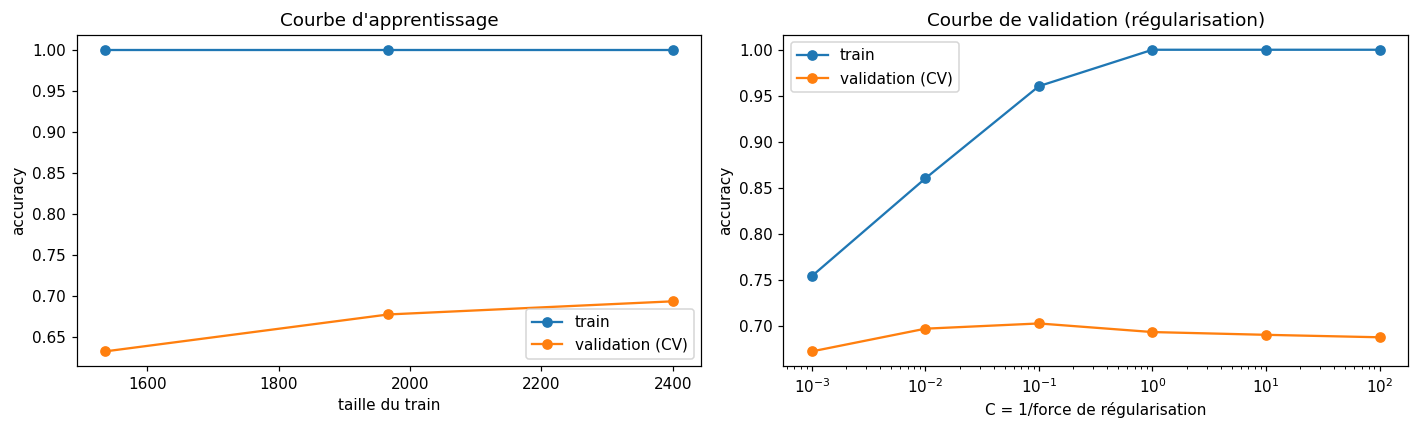

Meilleur C (max accuracy CV) : 0.1


In [43]:
# 1) Écart train vs test (sur/sous-apprentissage)
acc_tr = accuracy_score(y_train_raw, baseline.predict(Xtr_flat))
print(f"Accuracy train : {acc_tr:.3f} | test : {acc_ml:.3f} | écart : {acc_tr - acc_ml:+.3f}")

# Estimateur de référence (Ridge L2) pour les courbes
est = make_pipeline(StandardScaler(),
                    LogisticRegression(C=1.0, penalty="l2", solver="liblinear"))

# 2) Courbe d'apprentissage (biais/variance selon la taille du train)
sizes, tr_sc, cv_sc = learning_curve(
    est, Xtr_flat, y_train_raw, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)

# 3) Courbe de validation (effet de la régularisation C)
Cs = np.logspace(-3, 2, 6)
tr_c, cv_c = validation_curve(
    est, Xtr_flat, y_train_raw, param_name="logisticregression__C",
    param_range=Cs, cv=5, scoring="accuracy", n_jobs=-1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sizes, tr_sc.mean(1), "o-", label="train")
ax[0].plot(sizes, cv_sc.mean(1), "o-", label="validation (CV)")
ax[0].set_title("Courbe d'apprentissage"); ax[0].set_xlabel("taille du train")
ax[0].set_ylabel("accuracy"); ax[0].legend()

ax[1].plot(Cs, tr_c.mean(1), "o-", label="train")
ax[1].plot(Cs, cv_c.mean(1), "o-", label="validation (CV)")
ax[1].set_xscale("log"); ax[1].set_title("Courbe de validation (régularisation)")
ax[1].set_xlabel("C = 1/force de régularisation"); ax[1].set_ylabel("accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

best_C = Cs[cv_c.mean(1).argmax()]
print(f"Meilleur C (max accuracy CV) : {best_C:.3g}")

### 8.1 Lecture des courbes

Les chiffres parlent d'eux-mêmes : avec `C = 1`, la régression logistique obtient environ 0,979 d'accuracy en entraînement mais seulement 0,745 sur le test. Cet écart d'à peu près 0,234 est le signe d'un surapprentissage : le modèle mémorise une partie des 3072 pixels d'entrée au lieu de généraliser parfaitement. C'est donc surtout un problème de variance, pas de biais.

La courbe de validation confirme cette lecture : quand `C` est grand, la régularisation est faible, le score d'entraînement monte mais la validation décroche. En régularisant davantage, l'écart se réduit, et le meilleur compromis se situe autour de `C = 0,1`. Les trois pénalités jouent bien des rôles différents : Ridge stabilise tous les coefficients, Lasso sélectionne une partie des pixels utiles en annulant beaucoup de poids, et ElasticNet reste entre les deux.

La meilleure baseline reste Lasso, avec 0,745 d'accuracy et 0,831 d'AUC sur le test. C'est une base solide, mais elle travaille sur des pixels aplatis : elle ne comprend ni la géométrie du visage, ni les textures locales, ni les petites incohérences spatiales que peut laisser une génération artificielle. C'est précisément ce qui motive le passage aux modèles convolutifs.

# Partie 2 — Deep learning (CNN)

La baseline classique plafonne sur un manque de capacité. On passe maintenant au deep learning, avec
un réseau convolutif capable de tirer parti de la structure spatiale des images.

## 9. Architecture du réseau : pourquoi un CNN

Trois familles d'architectures se présentent. Un MLP (réseau dense) aplatit l'image en un long
vecteur : il perd la structure spatiale, multiplie les paramètres puisque chaque pixel est relié à
chaque neurone, et n'a aucune invariance par translation. Un RNN ou un LSTM est pensé pour des
séquences (texte, audio, séries temporelles) ; une image fixe n'est pas une séquence ordonnée dans
le temps, ça n'a pas de sens ici. Le CNN, lui, est fait pour des données à structure spatiale : ses
filtres convolutifs sont locaux et partagés sur toute l'image, ce qui apporte l'invariance par
translation, garde peu de paramètres et construit une hiérarchie de motifs, des contours aux
textures jusqu'aux structures du visage. C'est le bon choix : un deepfake laisse des défauts locaux
(transitions de peau, contours des yeux) qu'un filtre repère où qu'ils soient dans l'image.

À titre de comparaison, le MLP de référence fourni dans `models.py` (`build_mlp`) compte environ
12,6 millions de paramètres, contre seulement 28 000 pour notre CNN : l'écart illustre bien
l'avantage des convolutions.

Un mot sur la taille du réseau. Notre premier essai utilisait une version plus complète (blocs de
32, 64 puis 128 filtres, environ 110 000 paramètres) et atteignait autour de 85 % d'accuracy sur le
test. Mais chaque entraînement était long, ce qui rendait les essais successifs pénibles. On a donc
divisé par deux le nombre de filtres de chaque bloc (16, 32 puis 64, soit environ 28 000
paramètres) : on gagne à peu près un facteur deux par époque, de quoi enchaîner les expériences plus
facilement. Le revers, qu'on assume et qu'on retrouvera dans la comparaison, c'est que cette version
allégée perd une bonne part de la performance du modèle complet. L'architecture est définie dans
`models.py` (fonction `build_cnn`) ; le notebook se contente de l'instancier.

In [44]:
# Architecture définie dans models.py (modularité). On instancie simplement ici.
cnn = build_cnn(IMG_SIZE)
cnn.summary()

Model: "cnn_deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,257 (110.38 KB)

 Trainable params: 28,033 (109.50 KB)

 Non-trainable params: 224 (896.00 B)

## 10. Optimisation

Le choix de l'optimiseur. La descente de gradient stochastique (avec momentum) est simple mais
sensible au réglage du pas d'apprentissage. RMSprop adapte le pas par paramètre et se débrouille
bien sur des signaux changeants. Adam combine les deux idées, le momentum et le pas adaptatif :
il converge vite, demande peu de réglage et reste robuste, c'est donc notre choix par défaut. Plutôt
que de l'affirmer, on le vérifie juste après par une petite recherche d'hyperparamètres croisant
l'optimiseur et le pas d'apprentissage.

La question du vanishing/exploding gradient. Plusieurs choix de l'architecture visent justement à
garder des gradients exploitables en profondeur. L'activation ReLU a un gradient de 1 pour les
valeurs positives, elle ne sature donc pas comme une sigmoïde ou une tanh dont le gradient s'annule
aux extrêmes. La BatchNormalization après chaque convolution recentre et normalise les activations,
ce qui stabilise les gradients, accélère la convergence et rend le réseau moins dépendant de
l'initialisation. L'initialisation He, utilisée par défaut par Keras avec ReLU, adapte la variance
des poids à la profondeur pour éviter que le signal n'explose ou ne s'éteigne. Enfin, le couple
ReduceLROnPlateau et EarlyStopping (section 11) ajuste le pas et arrête l'entraînement avant la
divergence, et le Dropout limite le surapprentissage.

La recherche d'hyperparamètres ci-dessous reste volontairement légère (un sous-échantillon, peu
d'époques) : son but est de choisir une configuration, pas d'entraîner à fond. La meilleure servira
ensuite à l'entraînement complet.

In [45]:
# Recherche d'hyperparamètres LÉGÈRE : optimiseur x learning rate
# (sous-échantillon + peu d'époques, juste pour choisir une config sans exploser le temps de calcul)
SEARCH_N = 1500
SEARCH_EPOCHS = 2

sub = np.random.RandomState(RANDOM_STATE).permutation(len(X_train))[:SEARCH_N]
Xs, ys = X_train[sub], y_train[sub]

search_space = [("adam", 1e-2), ("adam", 1e-3), ("adam", 1e-4),
                ("sgd", 1e-2), ("rmsprop", 1e-3)]

rows = []
for opt_name, lr in search_space:
    m = build_cnn(IMG_SIZE, lr=lr, optimizer=opt_name)
    t0 = time.time()
    h = m.fit(Xs, ys, validation_data=(X_val, y_val),
              epochs=SEARCH_EPOCHS, batch_size=32, verbose=0)
    rows.append({"optimiseur": opt_name, "lr": lr,
                 "val_acc": round(max(h.history["val_accuracy"]), 4),
                 "val_auc": round(max(h.history["val_auc"]), 4),
                 "temps_s": round(time.time() - t0, 1)})
    print(f"  {opt_name:8s} lr={lr:<7} -> val_auc={rows[-1]['val_auc']:.3f}")

search_df = pd.DataFrame(rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
print(); print(search_df)

best = search_df.iloc[0]
BEST_OPT, BEST_LR = best["optimiseur"], float(best["lr"])
print(f"\nMeilleure config retenue : optimiseur={BEST_OPT}, learning_rate={BEST_LR}")

# On (re)construit le CNN final avec la meilleure config trouvée
cnn = build_cnn(IMG_SIZE, lr=BEST_LR, optimizer=BEST_OPT)

  adam     lr=0.01    -> val_auc=0.527
  adam     lr=0.001   -> val_auc=0.476
  adam     lr=0.0001  -> val_auc=0.509
  sgd      lr=0.01    -> val_auc=0.474
  rmsprop  lr=0.001   -> val_auc=0.460

  optimiseur      lr  val_acc  val_auc  temps_s
0       adam  0.0100   0.5167   0.5271     13.1
1       adam  0.0001   0.5000   0.5095     12.6
2       adam  0.0010   0.5067   0.4763     13.7
3        sgd  0.0100   0.5017   0.4737     12.3
4    rmsprop  0.0010   0.5000   0.4601     12.3

Meilleure config retenue : optimiseur=adam, learning_rate=0.01


## 11. Entraînement

On entraîne le CNN avec la configuration retenue à la section 10. EarlyStopping arrête
l'entraînement quand la perte de validation cesse de progresser, et ReduceLROnPlateau diminue le
pas d'apprentissage quand elle stagne. On chronomètre au passage la durée de l'entraînement, dont on
se servira pour la comparaison avec le modèle classique (section 13).

In [46]:
EPOCHS = 40

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=4, min_lr=1e-5),
]

t0 = time.time()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks, verbose=2,
)
t_dl = time.time() - t0
print(f"\nTemps d'entraînement CNN : {t_dl:.1f}s "
      f"({len(history.history['loss'])} époques effectives)")

Epoch 1/40
563/563 - 62s - 110ms/step - accuracy: 0.5124 - auc: 0.5180 - loss: 0.6985 - val_accuracy: 0.5133 - val_auc: 0.5190 - val_loss: 0.6941 - learning_rate: 0.0100
Epoch 2/40
563/563 - 61s - 108ms/step - accuracy: 0.5185 - auc: 0.5252 - loss: 0.6926 - val_accuracy: 0.4983 - val_auc: 0.5044 - val_loss: 0.6942 - learning_rate: 0.0100
Epoch 3/40
563/563 - 61s - 108ms/step - accuracy: 0.5228 - auc: 0.5284 - loss: 0.6922 - val_accuracy: 0.4817 - val_auc: 0.4797 - val_loss: 0.6975 - learning_rate: 0.0100
Epoch 4/40
563/563 - 61s - 108ms/step - accuracy: 0.5223 - auc: 0.5288 - loss: 0.6918 - val_accuracy: 0.5000 - val_auc: 0.4916 - val_loss: 0.6943 - learning_rate: 0.0100
Epoch 5/40
563/563 - 60s - 107ms/step - accuracy: 0.5072 - auc: 0.5065 - loss: 0.6931 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6933 - learning_rate: 0.0100
Epoch 6/40
563/563 - 64s - 114ms/step - accuracy: 0.5037 - auc: 0.5031 - loss: 0.6933 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6933 - le

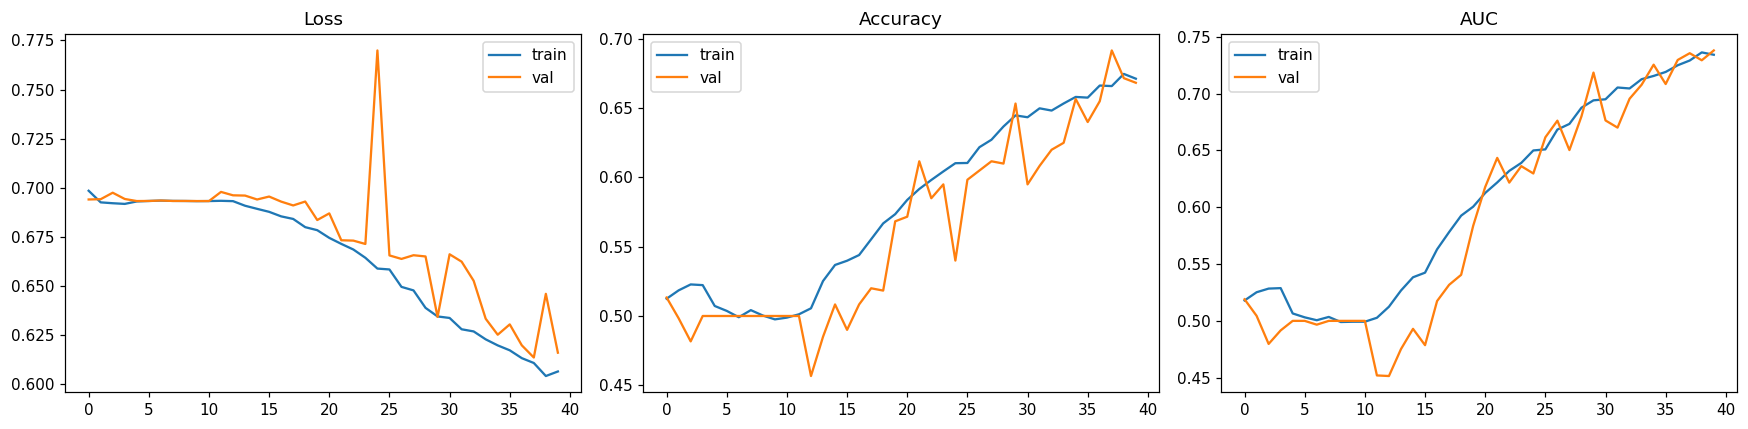

In [47]:
# Courbes d'apprentissage
h = history.history
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
ax[2].plot(h["auc"], label="train"); ax[2].plot(h["val_auc"], label="val")
ax[2].set_title("AUC"); ax[2].legend()
plt.tight_layout(); plt.show()

## 12. Évaluation du CNN sur le jeu de test

Accuracy (test) : 0.6767
ROC-AUC  (test) : 0.7439

              precision    recall  f1-score   support

        FAKE       0.66      0.73      0.69       300
        REAL       0.70      0.62      0.66       300

    accuracy                           0.68       600
   macro avg       0.68      0.68      0.68       600
weighted avg       0.68      0.68      0.68       600



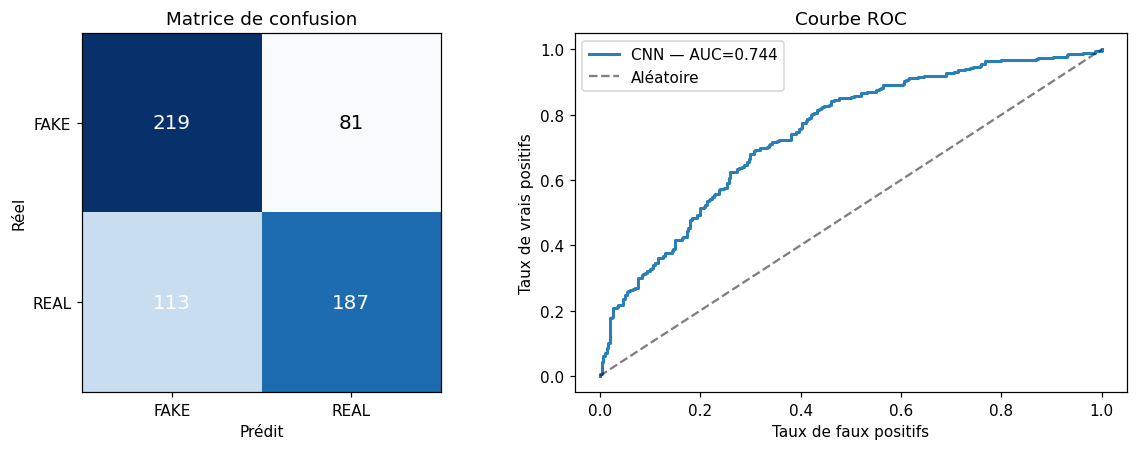

In [48]:
prob = cnn.predict(X_test, verbose=0).ravel()
pred = (prob >= 0.5).astype(int)

print(f"Accuracy (test) : {accuracy_score(y_test, pred):.4f}")
print(f"ROC-AUC  (test) : {roc_auc_score(y_test, prob):.4f}")
print()
print(classification_report(y_test, pred, target_names=["FAKE", "REAL"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cm = confusion_matrix(y_test, pred)
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1], ["FAKE", "REAL"]); ax[0].set_yticks([0, 1], ["FAKE", "REAL"])
ax[0].set_xlabel("Prédit"); ax[0].set_ylabel("Réel"); ax[0].set_title("Matrice de confusion")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, int(v), ha="center", va="center",
               color="white" if v > cm.max()/2 else "black", fontsize=13)

fpr, tpr, _ = roc_curve(y_test, prob)
ax[1].plot(fpr, tpr, color="#2980b9", lw=2,
           label=f"CNN — AUC={roc_auc_score(y_test, prob):.3f}")
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire")
ax[1].set_xlabel("Taux de faux positifs"); ax[1].set_ylabel("Taux de vrais positifs")
ax[1].set_title("Courbe ROC"); ax[1].legend()
plt.tight_layout(); plt.show()

### 12.1 Augmentation au moment du test (TTA)

Au lieu de prédire une seule fois sur chaque image de test, on en génère plusieurs variantes (les
mêmes transformations qu'à l'entraînement), on prédit sur toutes, puis on moyenne les probabilités.
Le jeu de test reste le même, on ne triche pas : on se contente de lisser la décision sur plusieurs
points de vue. En pratique ça réduit un peu la variance des prédictions et fait souvent gagner
quelques dixièmes de point, surtout sur les images limites.

TTA: 100%|██████████| 8/8 [00:05<00:00,  1.40it/s]


                 Accuracy     ROC-AUC
Sans TTA       :  0.6767      0.7439
Avec TTA       :  0.6700      0.7421

              precision    recall  f1-score   support

        FAKE       0.65      0.73      0.69       300
        REAL       0.69      0.61      0.65       300

    accuracy                           0.67       600
   macro avg       0.67      0.67      0.67       600
weighted avg       0.67      0.67      0.67       600



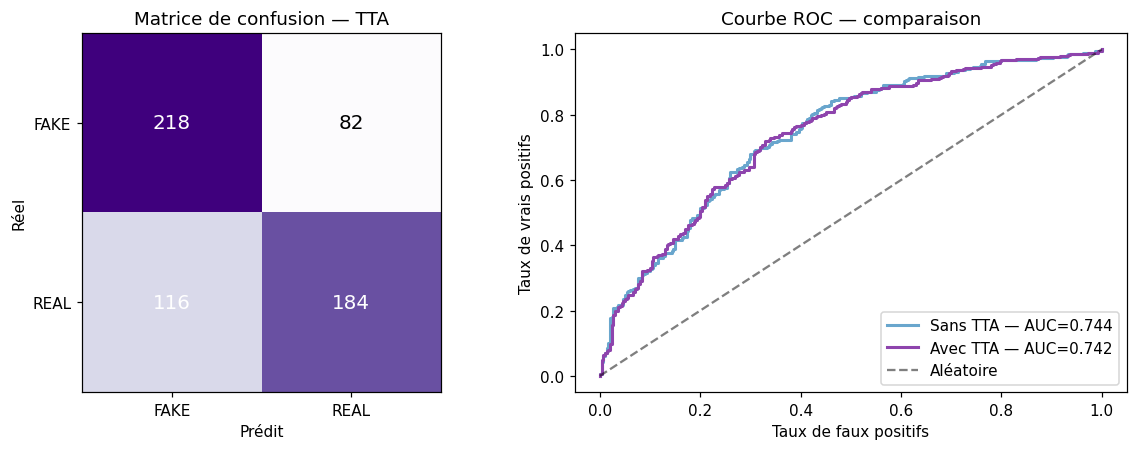

In [49]:
TTA_PASSES = 8     # nb de vues augmentées moyennées (en plus de l'image propre)

def tta_predict(model, X, n_passes=TTA_PASSES, seed=RANDOM_STATE):
    """Moyenne les probabilités sur l'image propre + n_passes variantes augmentées."""
    random.seed(seed); np.random.seed(seed)
    preds = [model.predict(X, verbose=0).ravel()]          # passe sur images propres
    for _ in tqdm(range(n_passes), total=n_passes, desc="TTA"):
        Xa = np.empty_like(X)
        for i in range(len(X)):
            img = _to_img(X[i])
            t = TRANSFORMS[random.randrange(len(TRANSFORMS))]
            try:
                Xa[i] = _to_arr(t(img))
            except Exception:
                Xa[i] = X[i]
        preds.append(model.predict(Xa, verbose=0).ravel())
    return np.mean(preds, axis=0)

prob_tta = tta_predict(cnn, X_test)
pred_tta = (prob_tta >= 0.5).astype(int)

# Comparaison sans TTA vs avec TTA
print("                 Accuracy     ROC-AUC")
print(f"Sans TTA       :  {accuracy_score(y_test, pred):.4f}      {roc_auc_score(y_test, prob):.4f}")
print(f"Avec TTA       :  {accuracy_score(y_test, pred_tta):.4f}      {roc_auc_score(y_test, prob_tta):.4f}")
print()
print(classification_report(y_test, pred_tta, target_names=["FAKE", "REAL"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cm = confusion_matrix(y_test, pred_tta)
ax[0].imshow(cm, cmap="Purples")
ax[0].set_xticks([0, 1], ["FAKE", "REAL"]); ax[0].set_yticks([0, 1], ["FAKE", "REAL"])
ax[0].set_xlabel("Prédit"); ax[0].set_ylabel("Réel")
ax[0].set_title("Matrice de confusion — TTA")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, int(v), ha="center", va="center",
               color="white" if v > cm.max()/2 else "black", fontsize=13)

fpr, tpr, _ = roc_curve(y_test, prob)
fpr_t, tpr_t, _ = roc_curve(y_test, prob_tta)
ax[1].plot(fpr, tpr, color="#2980b9", lw=2, alpha=0.7,
           label=f"Sans TTA — AUC={roc_auc_score(y_test, prob):.3f}")
ax[1].plot(fpr_t, tpr_t, color="#8e44ad", lw=2,
           label=f"Avec TTA — AUC={roc_auc_score(y_test, prob_tta):.3f}")
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire")
ax[1].set_xlabel("Taux de faux positifs"); ax[1].set_ylabel("Taux de vrais positifs")
ax[1].set_title("Courbe ROC — comparaison"); ax[1].legend()
plt.tight_layout(); plt.show()

## 13. Comparaison du modèle classique et du CNN

On met enfin face à face la régression logistique régularisée des sections 7 et 8 et le CNN (avec
et sans TTA), sur trois plans : la performance, les limites de chaque approche et le temps de calcul.

              Modèle  Accuracy  ROC-AUC  Temps entraînement (s)
Baseline LogReg (ML)  0.745000 0.831222                     8.4
            CNN (DL)  0.676667 0.743944                  2630.8
      CNN + TTA (DL)  0.670000 0.742111                  2630.8


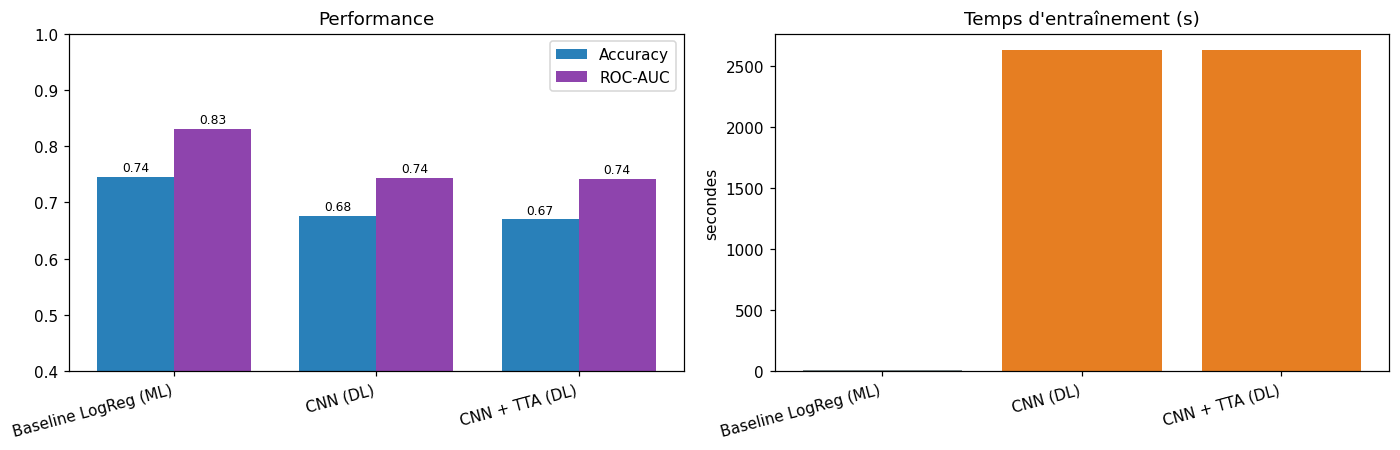

In [50]:
# Tableau récapitulatif (performances + temps de calcul)
compare = pd.DataFrame([
    {"Modèle": "Baseline LogReg (ML)", "Accuracy": acc_ml, "ROC-AUC": auc_ml,
     "Temps entraînement (s)": round(t_ml, 1)},
    {"Modèle": "CNN (DL)", "Accuracy": accuracy_score(y_test, pred),
     "ROC-AUC": roc_auc_score(y_test, prob), "Temps entraînement (s)": round(t_dl, 1)},
    {"Modèle": "CNN + TTA (DL)", "Accuracy": accuracy_score(y_test, pred_tta),
     "ROC-AUC": roc_auc_score(y_test, prob_tta), "Temps entraînement (s)": round(t_dl, 1)},
])
print(compare.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(compare)); w = 0.38
ax[0].bar(x - w/2, compare["Accuracy"], w, label="Accuracy", color="#2980b9")
ax[0].bar(x + w/2, compare["ROC-AUC"], w, label="ROC-AUC", color="#8e44ad")
ax[0].set_xticks(x, compare["Modèle"], rotation=15, ha="right")
ax[0].set_ylim(0.4, 1.0); ax[0].set_title("Performance"); ax[0].legend()
for xi, (a, au) in enumerate(zip(compare["Accuracy"], compare["ROC-AUC"])):
    ax[0].text(xi - w/2, a + .01, f"{a:.2f}", ha="center", fontsize=8)
    ax[0].text(xi + w/2, au + .01, f"{au:.2f}", ha="center", fontsize=8)

ax[1].bar(compare["Modèle"], compare["Temps entraînement (s)"],
          color=["#7f8c8d", "#e67e22", "#e67e22"])
ax[1].set_xticklabels(compare["Modèle"], rotation=15, ha="right")
ax[1].set_title("Temps d'entraînement (s)"); ax[1].set_ylabel("secondes")
plt.tight_layout(); plt.show()

### 13.1 Ce que dit la comparaison

La comparaison reste nuancée. La régression logistique régularisée atteint 0,745 d'accuracy et 0,831 d'AUC, tandis que le CNN compact atteint 0,677 d'accuracy et 0,744 d'AUC. La TTA n'améliore pas ce run : elle descend légèrement à 0,670 d'accuracy et 0,742 d'AUC. Autrement dit, le CNN apprend bien un signal au-dessus du hasard, mais il ne dépasse pas la baseline classique.

Ce résultat n'invalide pas le choix du CNN ; il montre surtout que l'entraînement d'un réseau depuis zéro est exigeant. La petite recherche d'hyperparamètres a retenu `Adam` avec un learning rate de `0,01`, alors que les essais courts donnaient tous des AUC proches de 0,5. Pendant l'entraînement final, le réseau progresse lentement : l'AUC validation monte jusqu'à environ 0,738 en fin de run, mais au prix d'un entraînement long de 2630,8 secondes. La capacité du modèle, le choix du pas d'apprentissage et le nombre d'images disponibles limitent donc fortement le résultat.

Le point important est le compromis performance/coût. La baseline s'entraîne en 8,4 secondes et reste la meilleure en AUC, alors que le CNN demande beaucoup plus de temps pour une performance inférieure. Cela prépare bien la suite : plutôt que d'apprendre tous les filtres depuis zéro, on va réutiliser des représentations visuelles déjà apprises avec le transfer learning.

## 14. Tester le modèle sur une image

Une fois entraîné, le modèle peut classer n'importe quel visage à partir de ses pixels, qu'il
vienne du jeu de test, d'un fichier local ou d'une URL. On le vérifie sur quelques images de test.

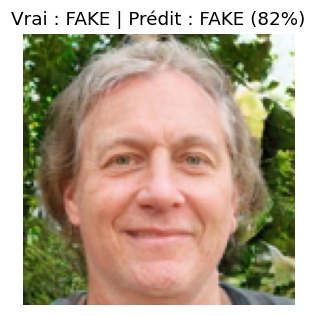

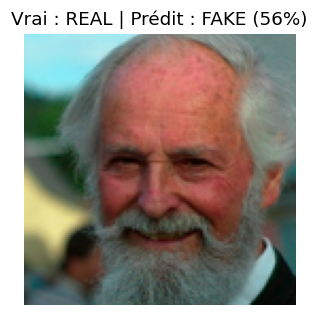

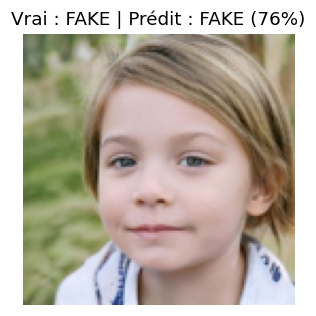

In [51]:
def predict_array(arr_uint8, show=True, true_label=None):
    """Classe une image (tenseur uint8 IMG_SIZE×IMG_SIZE×3)."""
    p = float(cnn.predict(arr_uint8[None, ...], verbose=0).ravel()[0])
    label = "REAL" if p >= 0.5 else "FAKE"
    conf = p if p >= 0.5 else 1 - p
    if show:
        plt.figure(figsize=(3.2, 3.2)); plt.imshow(arr_uint8); plt.axis("off")
        title = f"Prédit : {label} ({conf:.0%})"
        if true_label is not None:
            title = f"Vrai : {true_label} | " + title
        plt.title(title); plt.show()
    return label, p

def predict_url(url):
    """Classe une image téléchargée depuis une URL."""
    img = fetch_image(url)
    if img is None:
        print("Téléchargement impossible :", url); return
    arr = np.asarray(img.resize((IMG_SIZE, IMG_SIZE)), dtype="uint8")
    return predict_array(arr)

# Exemple : quelques images tirées du jeu de test
for i in np.random.RandomState(0).randint(0, len(X_test), size=3):
    vrai = "REAL" if y_test[i] == 1 else "FAKE"
    predict_array(X_test[i], true_label=vrai)

# Partie 3 — Deep learning avancé et déploiement

Les parties précédentes ont posé une baseline classique solide et un CNN entraîné de zéro. Pour le jalon avancé, on passe au **transfer learning** : au lieu d'apprendre tous les filtres depuis nos seules images, on réutilise MobileNetV2 pré-entraîné sur ImageNet.

Ce choix est adapté à la détection de deepfakes sur images : les premières couches de MobileNetV2 savent déjà extraire des bords, textures et contrastes locaux, qui sont justement utiles pour repérer des artefacts de génération. La base est gelée dans un premier temps pour limiter le temps de calcul et éviter de dégrader les poids pré-entraînés ; seule une petite tête de classification binaire est entraînée.

## 16. Transfer learning avec MobileNetV2

L'architecture avancée est définie dans `models.py` avec `build_transfer_mobilenet`, afin de garder le notebook centré sur l'orchestration et l'analyse. MobileNetV2 reçoit les images en 128×128, applique un prétraitement équivalent au format attendu par ImageNet, extrait des représentations visuelles déjà apprises, puis une tête dense prédit la probabilité que l'image soit réelle.

Le choix du transfer learning répond directement à la limite observée avec le CNN entraîné de zéro. Notre CNN compact devait apprendre à la fois les contours, textures, motifs de visage et artefacts de génération à partir de notre sous-échantillon. MobileNetV2 part au contraire de filtres déjà entraînés sur un très grand corpus d'images. Même si ImageNet ne contient pas spécifiquement des deepfakes, ses premières couches capturent des motifs génériques utiles : bords, transitions de couleur, textures fines, formes locales. On ne demande donc plus au modèle d'apprendre toute la vision depuis zéro, mais seulement d'adapter ces représentations au problème REAL/FAKE.

Dans cette première version avancée, la base MobileNetV2 est gelée. Ce choix réduit le risque de surapprentissage, accélère l'entraînement et évite de dégrader les poids pré-entraînés. La tête de classification reste volontairement légère, avec du dropout, pour apprendre une séparation binaire sans ajouter trop de paramètres.

In [52]:
transfer_model = build_transfer_mobilenet(IMG_SIZE, lr=1e-4, train_base=False)
transfer_model.summary()

Model: "mobilenetv2_deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 128, 128, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_out (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_real (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 17. Entraînement du modèle avancé

On entraîne seulement la tête de classification pendant 12 époques. `EarlyStopping` est prévu pour restaurer les meilleurs poids si la validation cesse de progresser, et `ReduceLROnPlateau` peut réduire le pas d'apprentissage en cas de stagnation. Dans cette exécution, l'entraînement va jusqu'au bout des 12 époques, ce qui indique que la validation continue globalement à s'améliorer.

Les courbes montrent une progression beaucoup plus saine que celle du CNN compact. L'accuracy validation passe de 0,710 à 0,733, et l'AUC validation de 0,764 à 0,827. Le modèle ne reste donc pas bloqué autour du hasard : il exploite bien les représentations pré-entraînées. Le temps d'entraînement est de 751,1 secondes, nettement inférieur au CNN compact qui demandait 2630,8 secondes, tout en produisant de meilleures métriques de test.

À la fin, le modèle est sauvegardé dans `artifacts/deepfake_mobilenetv2.keras`. Cette sauvegarde sert de pont entre le notebook expérimental et le dashboard Streamlit : l'application n'a pas besoin de réentraîner le modèle, elle charge directement l'artefact généré.

In [53]:
TRANSFER_EPOCHS = 12
TRANSFER_MODEL_PATH = "artifacts/deepfake_mobilenetv2.keras"

callbacks_transfer = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=2, min_lr=1e-6),
]

t0 = time.time()
history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=TRANSFER_EPOCHS, batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks_transfer, verbose=2,
)
t_transfer = time.time() - t0

os.makedirs("artifacts", exist_ok=True)
transfer_model.save(TRANSFER_MODEL_PATH)
print(f"\nTemps d'entraînement MobileNetV2 : {t_transfer:.1f}s "
      f"({len(history_transfer.history['loss'])} époques effectives)")
print("Modèle sauvegardé dans :", TRANSFER_MODEL_PATH)

Epoch 1/12
563/563 - 71s - 127ms/step - accuracy: 0.6007 - auc: 0.6354 - loss: 0.6976 - val_accuracy: 0.7100 - val_auc: 0.7637 - val_loss: 0.6055 - learning_rate: 1.0000e-04
Epoch 2/12
563/563 - 65s - 115ms/step - accuracy: 0.6627 - auc: 0.7147 - loss: 0.6211 - val_accuracy: 0.7133 - val_auc: 0.7869 - val_loss: 0.5809 - learning_rate: 1.0000e-04
Epoch 3/12
563/563 - 61s - 108ms/step - accuracy: 0.6663 - auc: 0.7290 - loss: 0.6100 - val_accuracy: 0.7200 - val_auc: 0.7991 - val_loss: 0.5707 - learning_rate: 1.0000e-04
Epoch 4/12
563/563 - 60s - 107ms/step - accuracy: 0.6829 - auc: 0.7471 - loss: 0.5938 - val_accuracy: 0.7167 - val_auc: 0.8039 - val_loss: 0.5584 - learning_rate: 1.0000e-04
Epoch 5/12
563/563 - 68s - 120ms/step - accuracy: 0.6893 - auc: 0.7606 - loss: 0.5813 - val_accuracy: 0.7200 - val_auc: 0.8105 - val_loss: 0.5561 - learning_rate: 1.0000e-04
Epoch 6/12
563/563 - 67s - 120ms/step - accuracy: 0.7009 - auc: 0.7714 - loss: 0.5716 - val_accuracy: 0.7283 - val_auc: 0.8141 - v

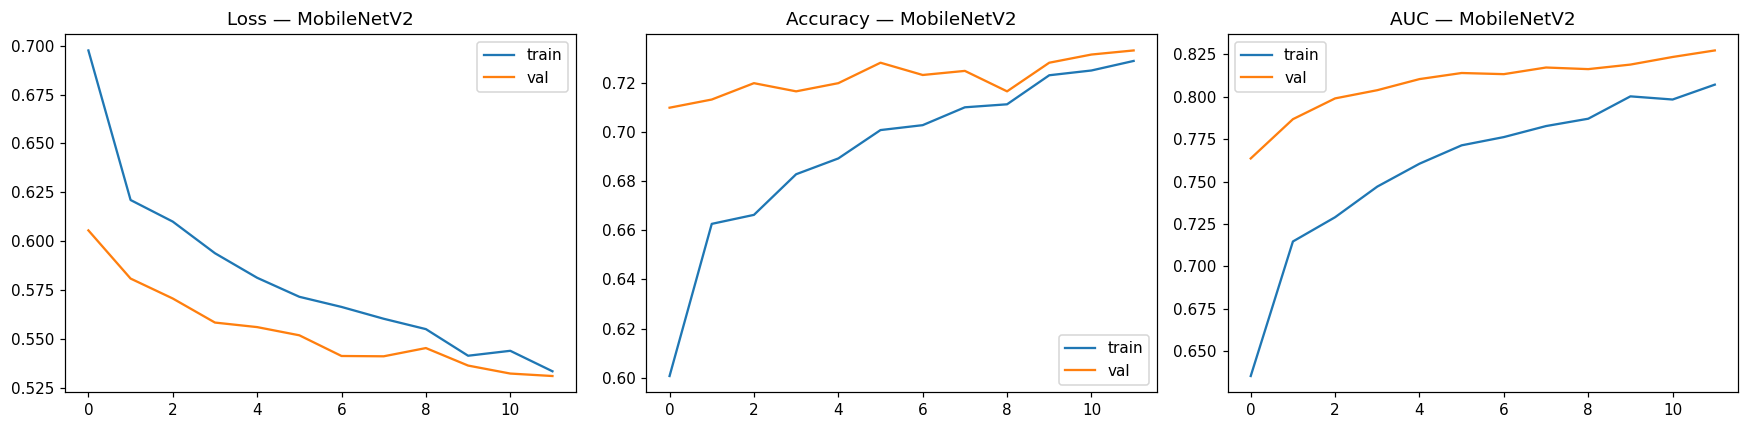

In [54]:
ht = history_transfer.history
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(ht["loss"], label="train"); ax[0].plot(ht["val_loss"], label="val")
ax[0].set_title("Loss — MobileNetV2"); ax[0].legend()
ax[1].plot(ht["accuracy"], label="train"); ax[1].plot(ht["val_accuracy"], label="val")
ax[1].set_title("Accuracy — MobileNetV2"); ax[1].legend()
ax[2].plot(ht["auc"], label="train"); ax[2].plot(ht["val_auc"], label="val")
ax[2].set_title("AUC — MobileNetV2"); ax[2].legend()
plt.tight_layout(); plt.show()

## 18. Évaluation du modèle avancé

MobileNetV2 est évalué sur le même jeu de test que les autres modèles. Il obtient 0,705 d'accuracy et 0,804 d'AUC. Le gain par rapport au CNN compact est net : environ +2,8 points d'accuracy et +6,0 points d'AUC. Le modèle avancé n'atteint pas l'AUC de la régression logistique, mais il améliore clairement la partie deep learning et valide l'intérêt du transfer learning.

Le rapport de classification révèle un comportement intéressant : la classe FAKE est mieux rappelée (`recall = 0,84`) que la classe REAL (`recall = 0,57`). Le modèle est donc plus agressif pour détecter les faux visages, quitte à classer certains vrais visages comme faux. Dans un contexte de détection de deepfakes, ce biais peut être défendable si l'objectif est de repérer un maximum de contenus suspects, mais il augmente le nombre de faux positifs. C'est une limite importante à signaler.

L'AUC de 0,804 montre que les probabilités restent informatives au-delà du seuil fixe de 0,5. Autrement dit, le modèle classe encore imparfaitement au seuil choisi, mais il ordonne les exemples de manière assez pertinente. Une amélioration naturelle serait donc d'ajuster le seuil selon l'usage : seuil plus bas pour détecter plus de faux, seuil plus haut pour éviter d'accuser trop d'images réelles.

Accuracy MobileNetV2 (test) : 0.7050
ROC-AUC  MobileNetV2 (test) : 0.8039

              precision    recall  f1-score   support

        FAKE       0.66      0.84      0.74       300
        REAL       0.78      0.57      0.66       300

    accuracy                           0.70       600
   macro avg       0.72      0.71      0.70       600
weighted avg       0.72      0.70      0.70       600



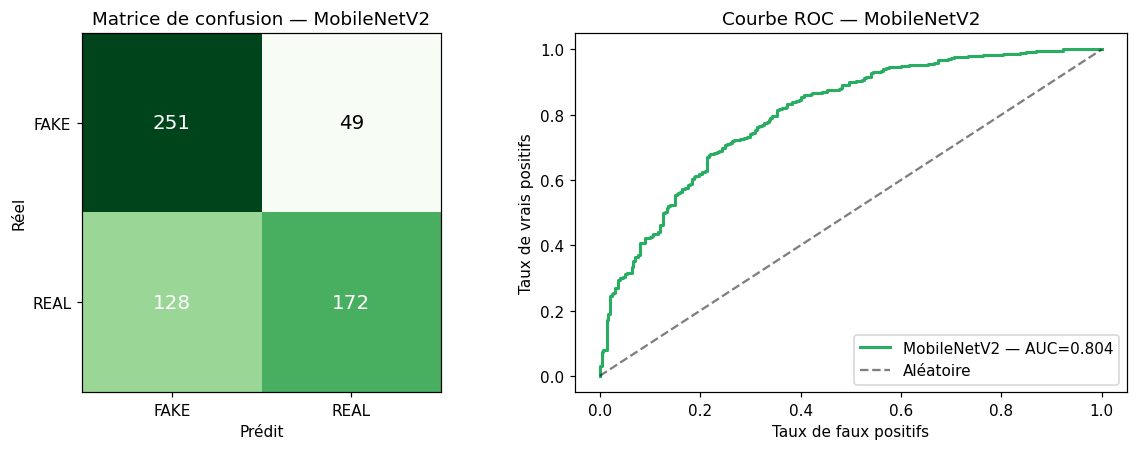

In [55]:
prob_transfer = transfer_model.predict(X_test, verbose=0).ravel()
pred_transfer = (prob_transfer >= 0.5).astype(int)

acc_transfer = accuracy_score(y_test, pred_transfer)
auc_transfer = roc_auc_score(y_test, prob_transfer)

print(f"Accuracy MobileNetV2 (test) : {acc_transfer:.4f}")
print(f"ROC-AUC  MobileNetV2 (test) : {auc_transfer:.4f}")
print()
print(classification_report(y_test, pred_transfer, target_names=["FAKE", "REAL"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cm_transfer = confusion_matrix(y_test, pred_transfer)
im = ax[0].imshow(cm_transfer, cmap="Greens")
ax[0].set_xticks([0, 1], ["FAKE", "REAL"]); ax[0].set_yticks([0, 1], ["FAKE", "REAL"])
ax[0].set_xlabel("Prédit"); ax[0].set_ylabel("Réel"); ax[0].set_title("Matrice de confusion — MobileNetV2")
for (i, j), v in np.ndenumerate(cm_transfer):
    ax[0].text(j, i, int(v), ha="center", va="center",
               color="white" if v > cm_transfer.max()/2 else "black", fontsize=13)

fpr_t, tpr_t, _ = roc_curve(y_test, prob_transfer)
ax[1].plot(fpr_t, tpr_t, color="#27ae60", lw=2,
           label=f"MobileNetV2 — AUC={auc_transfer:.3f}")
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire")
ax[1].set_xlabel("Taux de faux positifs"); ax[1].set_ylabel("Taux de vrais positifs")
ax[1].set_title("Courbe ROC — MobileNetV2"); ax[1].legend()
plt.tight_layout(); plt.show()

## 19. Comparaison finale

La comparaison finale montre trois niveaux de lecture. La baseline classique reste très compétitive : elle obtient la meilleure AUC, 0,831, en seulement 8,4 secondes d'entraînement. C'est un résultat fort, qui indique que certaines différences globales ou corrélations de pixels du dataset sont déjà captées par un modèle linéaire régularisé.

Le CNN compact entraîné de zéro progresse, mais reste en retrait : 0,677 d'accuracy et 0,744 d'AUC pour 2630,8 secondes d'entraînement. La TTA n'apporte pas de gain sur ce run et descend légèrement à 0,670 d'accuracy. Cela confirme que l'augmentation au test ne compense pas un modèle encore insuffisamment robuste.

MobileNetV2 occupe une position intermédiaire mais plus intéressante côté deep learning : 0,705 d'accuracy, 0,804 d'AUC, et 751,1 secondes d'entraînement. Il bat clairement le CNN tout en étant environ 3,5 fois plus rapide. Même s'il ne dépasse pas la baseline en AUC, il démontre l'intérêt de réutiliser une représentation visuelle pré-entraînée plutôt que de repartir de zéro.

                         Modèle  Accuracy  ROC-AUC  Temps entraînement (s)
           Baseline LogReg (ML)  0.745000 0.831222                     8.4
                       CNN (DL)  0.676667 0.743944                  2630.8
                 CNN + TTA (DL)  0.670000 0.742111                  2630.8
MobileNetV2 (Transfer Learning)  0.705000 0.803856                   751.1


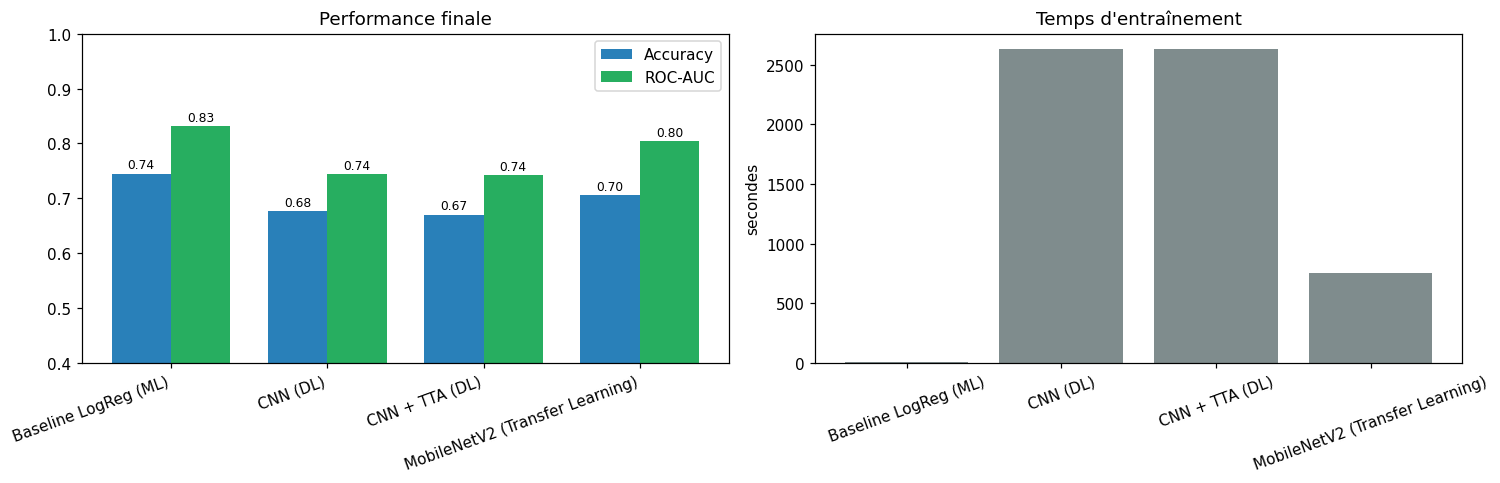

In [56]:
final_compare = pd.DataFrame([
    {"Modèle": "Baseline LogReg (ML)", "Accuracy": acc_ml, "ROC-AUC": auc_ml,
     "Temps entraînement (s)": round(t_ml, 1)},
    {"Modèle": "CNN (DL)", "Accuracy": accuracy_score(y_test, pred),
     "ROC-AUC": roc_auc_score(y_test, prob), "Temps entraînement (s)": round(t_dl, 1)},
    {"Modèle": "CNN + TTA (DL)", "Accuracy": accuracy_score(y_test, pred_tta),
     "ROC-AUC": roc_auc_score(y_test, prob_tta), "Temps entraînement (s)": round(t_dl, 1)},
    {"Modèle": "MobileNetV2 (Transfer Learning)", "Accuracy": acc_transfer,
     "ROC-AUC": auc_transfer, "Temps entraînement (s)": round(t_transfer, 1)},
])
print(final_compare.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(final_compare)); w = 0.38
ax[0].bar(x - w/2, final_compare["Accuracy"], w, label="Accuracy", color="#2980b9")
ax[0].bar(x + w/2, final_compare["ROC-AUC"], w, label="ROC-AUC", color="#27ae60")
ax[0].set_xticks(x, final_compare["Modèle"], rotation=20, ha="right")
ax[0].set_ylim(0.4, 1.0); ax[0].set_title("Performance finale"); ax[0].legend()
for xi, (a, au) in enumerate(zip(final_compare["Accuracy"], final_compare["ROC-AUC"])):
    ax[0].text(xi - w/2, a + .01, f"{a:.2f}", ha="center", fontsize=8)
    ax[0].text(xi + w/2, au + .01, f"{au:.2f}", ha="center", fontsize=8)

ax[1].bar(final_compare["Modèle"], final_compare["Temps entraînement (s)"], color="#7f8c8d")
ax[1].set_title("Temps d'entraînement")
ax[1].set_ylabel("secondes")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 20. Déploiement Streamlit

Le modèle MobileNetV2 sauvegardé est exploité par `app.py`. Le dashboard charge `artifacts/deepfake_mobilenetv2.keras`, accepte une image uploadée, applique le même redimensionnement que le notebook et affiche la prédiction `REAL` ou `FAKE` avec une confiance.

Commande locale :

```bash
streamlit run app.py
```

Ce dashboard transforme le modèle en outil exploitable : au lieu de rester dans une cellule de notebook, la prédiction devient accessible via une interface simple. C'est aussi une manière de vérifier la cohérence de toute la chaîne : preprocessing, chargement du modèle, inférence et affichage du résultat.

Si le fichier `.keras` est absent, l'application affiche un message clair demandant d'exécuter la Partie 3 du notebook avant de lancer le dashboard. Le modèle est ignoré par Git via `.gitignore`, afin d'éviter de pousser un artefact binaire lourd ; il doit donc être régénéré localement en exécutant le notebook.

## 21. Conclusion

La partie 1 pose une baseline solide. La régression logistique régularisée compare Ridge, Lasso et ElasticNet ; Lasso est retenu avec 0,745 d'accuracy et 0,831 d'AUC sur le test. L'analyse biais/variance montre un surapprentissage net : 0,979 d'accuracy en entraînement contre 0,745 sur le test. La régularisation limite ce phénomène, mais le modèle reste linéaire et travaille sur des pixels aplatis.

La partie 2 introduit le deep learning fondamental. Le CNN est justifié par la structure spatiale des images, et l'architecture utilise ReLU, BatchNormalization, Dropout, EarlyStopping et ReduceLROnPlateau pour stabiliser l'entraînement. Sur ce run, le CNN atteint 0,677 d'accuracy et 0,744 d'AUC, ce qui reste inférieur à la baseline. Ce résultat montre que le deep learning n'est pas automatiquement supérieur : sans bonne initialisation, capacité suffisante et réglage fin, un CNN compact peut coûter cher tout en généralisant moins bien qu'un modèle classique.

La partie 3 apporte le jalon avancé avec MobileNetV2 pré-entraîné sur ImageNet. Le transfer learning améliore nettement l'approche deep learning : 0,705 d'accuracy et 0,804 d'AUC, avec un temps d'entraînement de 751,1 secondes contre 2630,8 secondes pour le CNN compact. Le modèle détecte bien les faux visages en rappel (`recall FAKE = 0,84`), mais il confond encore une partie des vrais visages avec des faux (`recall REAL = 0,57`). C'est donc un modèle utile pour filtrer des contenus suspects, mais pas encore suffisant pour une décision automatique sans contrôle humain.

La limite principale reste le dataset : les faux viennent de StyleGAN. Les modèles peuvent donc apprendre des traces propres à ce générateur et généraliser imparfaitement à des deepfakes issus de diffusion, de face swap vidéo ou d'autres pipelines. Pour aller plus loin, il faudrait varier les sources de faux, ajuster le seuil de décision selon le coût des faux positifs/faux négatifs, tester un fine-tuning partiel de MobileNetV2 et analyser les erreurs image par image.

Le dashboard Streamlit finalise la chaîne en rendant le modèle exploitable hors notebook. Il charge le modèle sauvegardé, accepte une image et affiche une prédiction avec confiance. Le projet passe donc d'une expérimentation Data Science à un prototype utilisable, tout en restant transparent sur ses limites.